# Final Project Results

## GCN Baseline

In [38]:
import sys
from pathlib import Path

# Allows importing from the project root
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root))

Imports

In [39]:
import torch
import matplotlib.pyplot as plt

from src.gcn_baseline import run_experiment

Pick dataset

In [40]:
dataset_name = "Cora"  # "CiteSeer" or "Cora"

if dataset_name.lower() == "citeseer":
    dataset_name = "CiteSeer"

dataset_name

'Cora'

Run the GCN experiment

In [41]:
model, dataset, data, results = run_experiment(dataset_name, epochs=200)

losses = results["losses"]
val_accuracies = results["val_accuracies"]

model

Dataset: Cora
Nodes: 2708
Edges: 10556
Features per node: 1433
Classes: 7
Train nodes: 140
Validation nodes: 500
Test nodes: 1000
Epoch: 1 Loss: 1.9462 Val acc: 0.23
Epoch: 20 Loss: 1.7253 Val acc: 0.702
Epoch: 40 Loss: 1.342 Val acc: 0.744
Epoch: 60 Loss: 0.9602 Val acc: 0.786
Epoch: 80 Loss: 0.6772 Val acc: 0.802
Epoch: 100 Loss: 0.5734 Val acc: 0.798
Epoch: 120 Loss: 0.4659 Val acc: 0.798
Epoch: 140 Loss: 0.4161 Val acc: 0.794
Epoch: 160 Loss: 0.3846 Val acc: 0.804
Epoch: 180 Loss: 0.348 Val acc: 0.798
Epoch: 200 Loss: 0.3272 Val acc: 0.792

Final results:
Train accuracy: 1.0
Validation accuracy: 0.792
Test accuracy: 0.802


GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)

Check what was saved from training

In [42]:
print("Epochs recorded:", len(losses))
print("Last loss:", round(losses[-1], 4))
print("Last validation accuracy:", round(val_accuracies[-1], 4))

Epochs recorded: 200
Last loss: 0.3272
Last validation accuracy: 0.792


Final accuracy for the GCN baseline

In [43]:
print("GCN results for", dataset_name)
print("Train accuracy:", round(results["train_acc"], 4))
print("Validation accuracy:", round(results["val_acc"], 4))
print("Test accuracy:", round(results["test_acc"], 4))

GCN results for Cora
Train accuracy: 1.0
Validation accuracy: 0.792
Test accuracy: 0.802


Plots

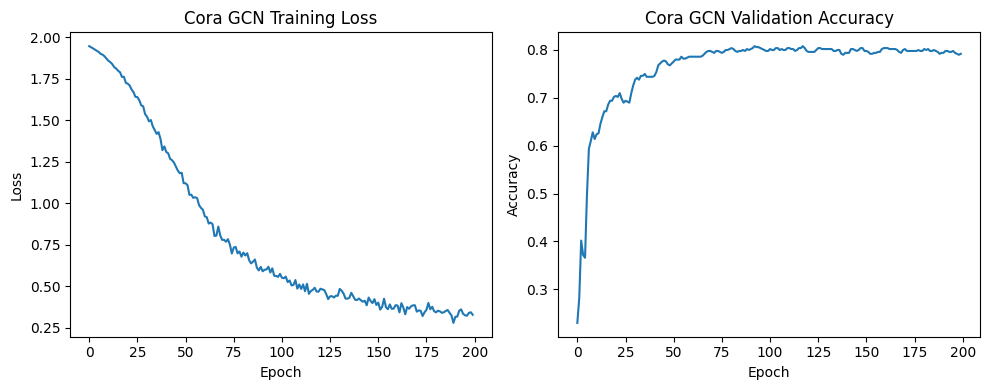

In [44]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title(dataset_name + " GCN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(val_accuracies)
plt.title(dataset_name + " GCN Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()